# Job Satisfaction Prediction
**Goal:** Build a classification model to predict whether an employee is satisfied (1) or not (0).

**Pipeline:**
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Feature Engineering & Preprocessing
4. Model Training
5. Evaluation
6. Feature Importance (SHAP)

## 1. Setup & Data Loading

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [26]:
# Load the dataset
df = pd.read_csv('job_satisfaction.csv', index_col=0)

print(f'Shape: {df.shape}')
df.head(10)

Shape: (500, 13)


,emp_id,age,Dept,location,education,recruitment_type,job_level,rating,onsite,awards,certifications,salary,satisfied
0,HR8270,28,HR,Suburb,PG,Referral,5,2,0,1,0,86750,1
1,TECH1860,50,Technology,Suburb,PG,Walk-in,3,5,1,2,1,42419,0
2,TECH6390,43,Technology,Suburb,UG,Referral,4,1,0,2,0,65715,0
3,SAL6191,44,Sales,City,PG,On-Campus,2,3,1,0,0,29805,1
4,HR6734,33,HR,City,UG,Recruitment Agency,2,1,0,5,0,29805,1
5,PUR7265,40,Purchasing,Suburb,UG,Referral,3,3,0,7,1,42419,1
6,PUR1466,26,Purchasing,Suburb,UG,Referral,5,5,0,2,0,86750,0
7,TECH5426,25,Technology,City,UG,Recruitment Agency,1,1,0,4,0,24076,0
8,HR6578,35,HR,City,PG,Referral,3,4,0,0,0,42419,1
9,TECH9322,45,Technology,City,PG,Referral,3,3,0,9,0,42419,0


## 2. Exploratory Data Analysis (EDA)

In [27]:
# Basic info: dtypes, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   emp_id            500 non-null    object
 1   age               500 non-null    int64 
 2   Dept              500 non-null    object
 3   location          500 non-null    object
 4   education         500 non-null    object
 5   recruitment_type  500 non-null    object
 6   job_level         500 non-null    int64 
 7   rating            500 non-null    int64 
 8   onsite            500 non-null    int64 
 9   awards            500 non-null    int64 
 10  certifications    500 non-null    int64 
 11  salary            500 non-null    int64 
 12  satisfied         500 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 54.7+ KB


In [28]:
# Summary statistics for numeric columns
df.describe()

,age,job_level,rating,onsite,awards,certifications,salary,satisfied
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,38.610000,3.032000,3.072000,0.466000,4.538000,0.496000,50416.056000,0.526000
std,9.438648,1.423738,1.425089,0.499342,2.853215,0.500485,23671.392661,0.499824
min,23.000000,1.000000,1.000000,0.000000,0.000000,0.000000,24076.000000,0.000000
25%,30.000000,2.000000,2.000000,0.000000,2.000000,0.000000,29805.000000,0.000000
50%,39.000000,3.000000,3.000000,0.000000,5.000000,0.000000,42419.000000,1.000000
75%,47.000000,4.000000,4.000000,1.000000,7.000000,1.000000,65715.000000,1.000000
max,54.000000,5.000000,5.000000,1.000000,9.000000,1.000000,86750.000000,1.000000


In [29]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:', missing)
print(missing[missing > 0] if missing.any() else 'No missing values found.')

Missing values per column: emp_id              0
age                 0
Dept                0
location            0
education           0
recruitment_type    0
job_level           0
rating              0
onsite              0
awards              0
certifications      0
salary              0
satisfied           0
dtype: int64
No missing values found.


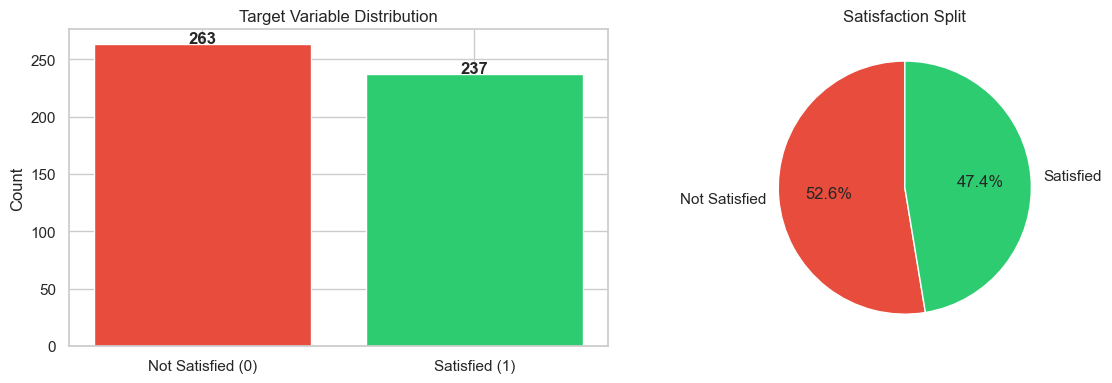

In [30]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['satisfied'].value_counts()
axes[0].bar(['Not Satisfied (0)', 'Satisfied (1)'], counts.values, color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Target Variable Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Not Satisfied', 'Satisfied'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Satisfaction Split')

plt.tight_layout()
plt.show()

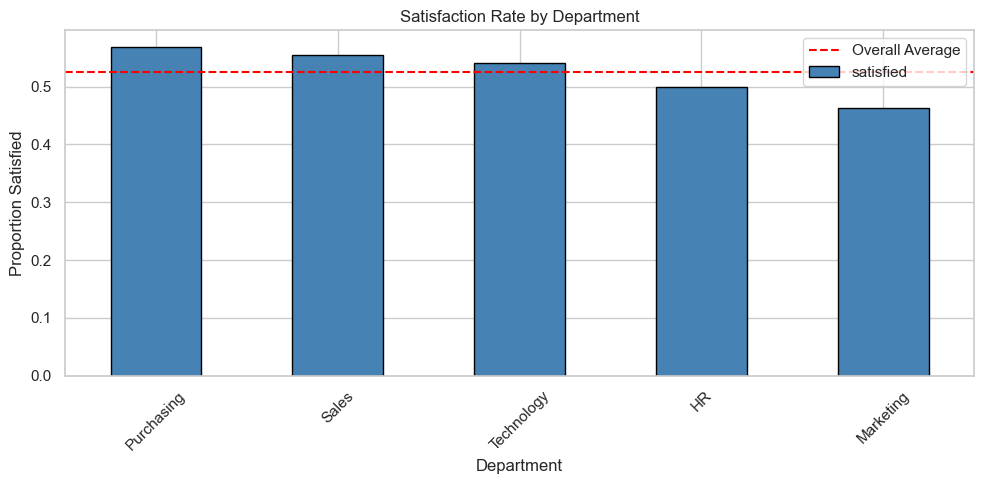

In [31]:
# Satisfaction rate by Department
dept_sat = df.groupby('Dept')['satisfied'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
dept_sat.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Satisfaction Rate by Department')
plt.ylabel('Proportion Satisfied')
plt.xlabel('Department')
plt.xticks(rotation=45)
plt.axhline(df['satisfied'].mean(), color='red', linestyle='--', label='Overall Average')
plt.legend()
plt.tight_layout()
plt.show()

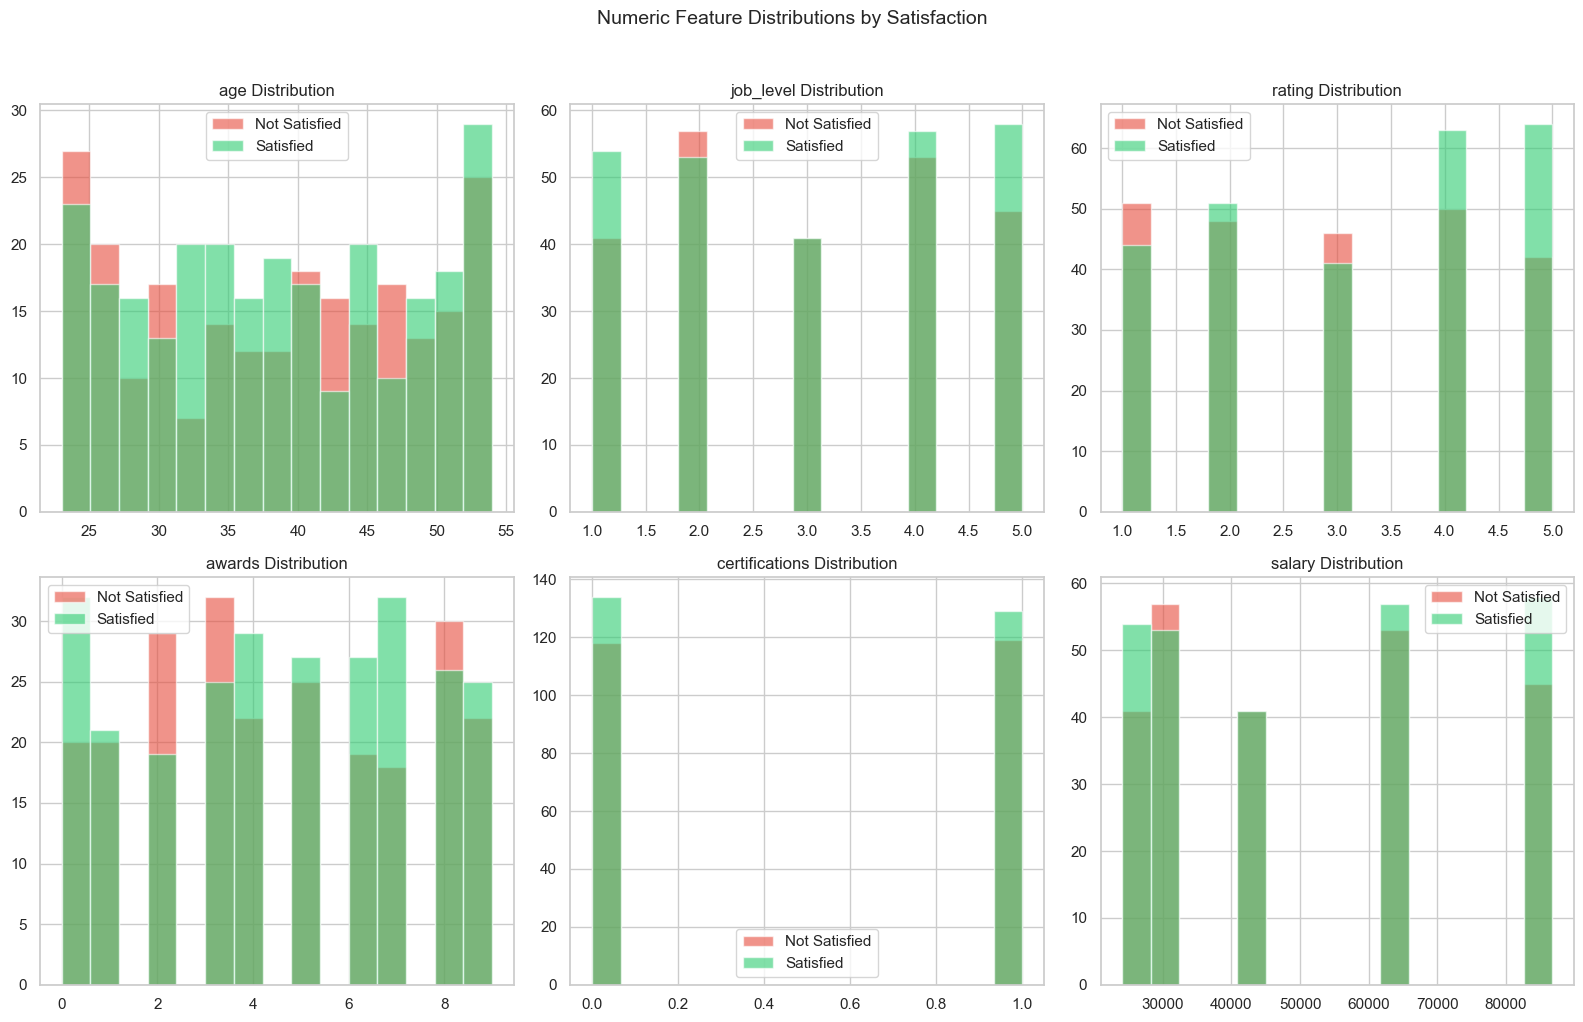

In [32]:
# Distributions of numeric features by satisfaction
numeric_cols = ['age', 'job_level', 'rating', 'awards', 'certifications', 'salary']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[df['satisfied'] == 0][col].hist(ax=axes[i], alpha=0.6, color='#e74c3c', label='Not Satisfied', bins=15)
    df[df['satisfied'] == 1][col].hist(ax=axes[i], alpha=0.6, color='#2ecc71', label='Satisfied', bins=15)
    axes[i].set_title(f'{col} Distribution')
    axes[i].legend()

plt.suptitle('Numeric Feature Distributions by Satisfaction', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

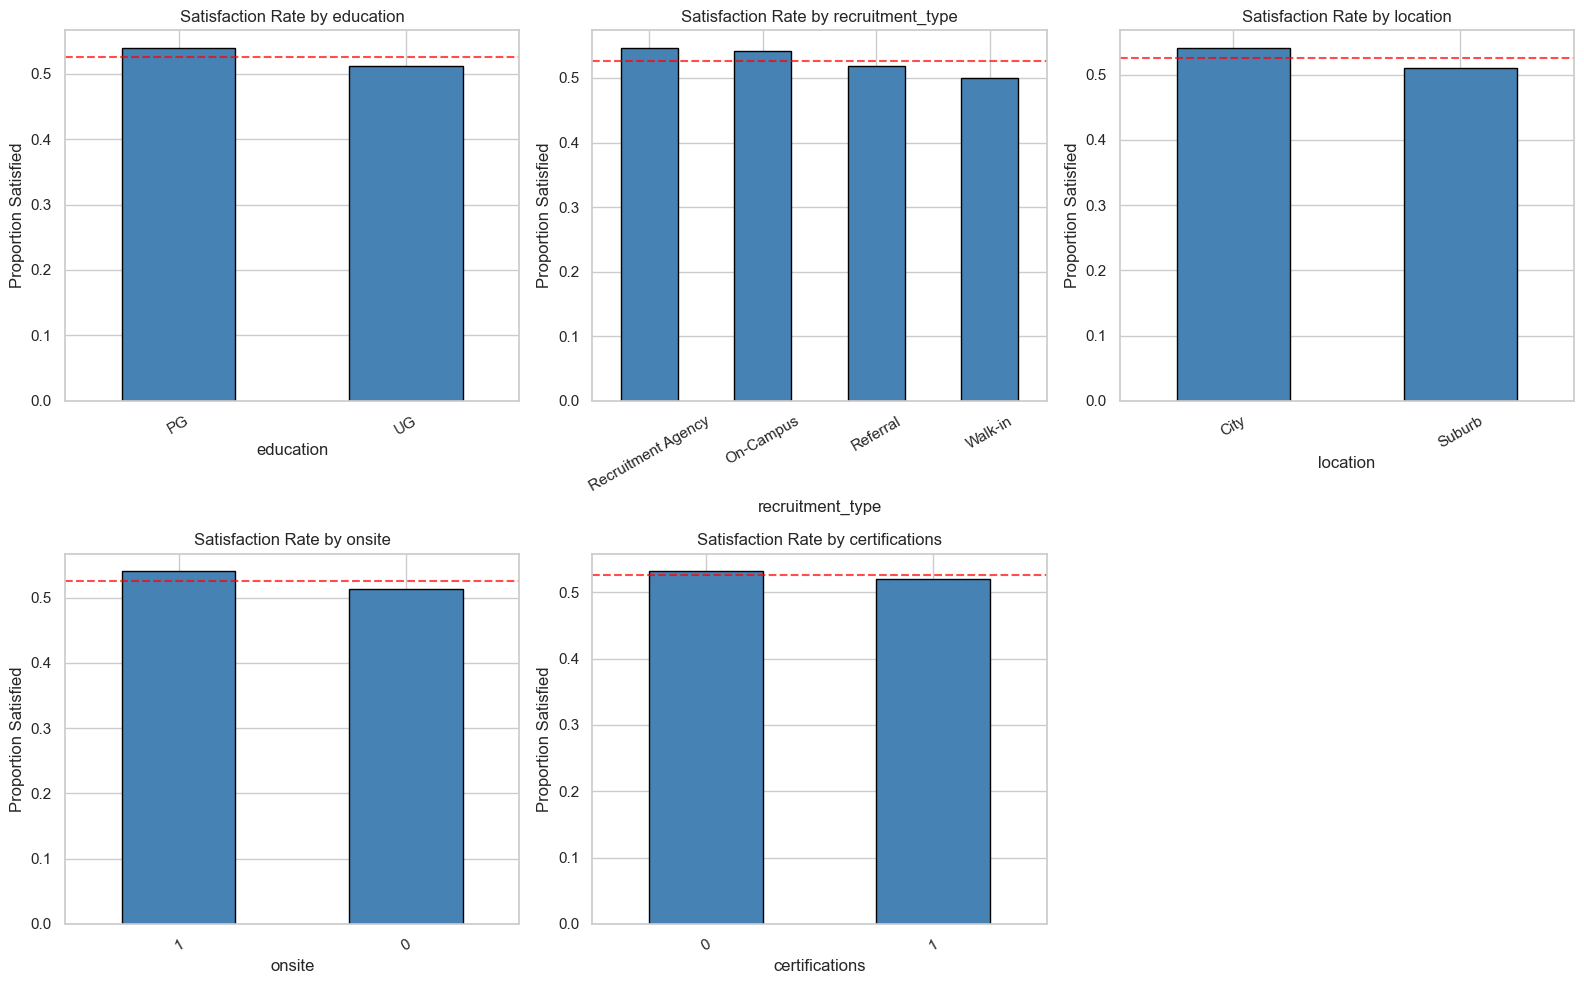

In [33]:
# Satisfaction rate across categorical features
cat_cols = ['education', 'recruitment_type', 'location', 'onsite', 'certifications']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sat_rate = df.groupby(col)['satisfied'].mean().sort_values(ascending=False)
    sat_rate.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Satisfaction Rate by {col}')
    axes[i].set_ylabel('Proportion Satisfied')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30)
    axes[i].axhline(df['satisfied'].mean(), color='red', linestyle='--', alpha=0.7)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

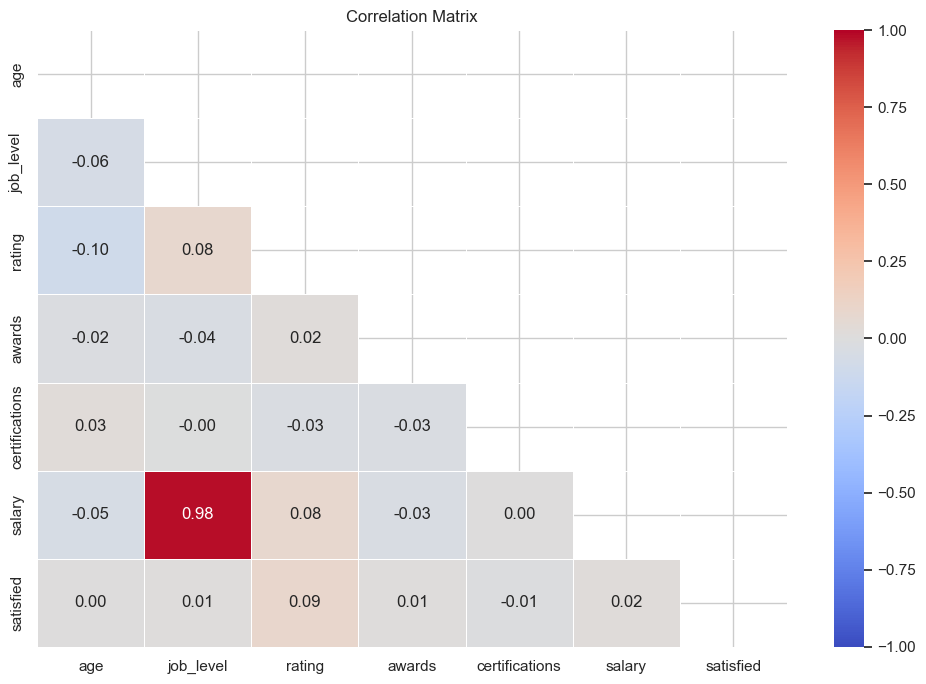

In [34]:
# Correlation heatmap (numeric features only)
numeric_df = df[numeric_cols + ['satisfied']]

plt.figure(figsize=(10, 7))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 3. Feature Engineering & Preprocessing

In [35]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Drop identifier column (emp_id has no predictive value)
df_model = df.drop(columns=['emp_id'])

# Encode categorical columns
cat_features = ['Dept', 'location', 'education', 'recruitment_type']
le = LabelEncoder()

for col in cat_features:
    df_model[col] = le.fit_transform(df_model[col])

print('Encoded columns:', cat_features)
df_model.head()

Encoded columns: ['Dept', 'location', 'education', 'recruitment_type']


,age,Dept,location,education,recruitment_type,job_level,rating,onsite,awards,certifications,salary,satisfied
0,28,0,1,0,2,5,2,0,1,0,86750,1
1,50,4,1,0,3,3,5,1,2,1,42419,0
2,43,4,1,1,2,4,1,0,2,0,65715,0
3,44,3,0,0,0,2,3,1,0,0,29805,1
4,33,0,0,1,1,2,1,0,5,0,29805,1


In [36]:
# Define features (X) and target (y)
X = df_model.drop(columns=['satisfied'])
y = df_model['satisfied']

print(f'Features shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')

Features shape: (500, 11)
Target distribution:
satisfied
1    263
0    237
Name: count, dtype: int64


In [43]:
# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]}')
print(f'Test size:  {X_test.shape[0]}')
print(f'Train satisfaction rate: {y_train.mean():.2%}')
print(f'Test satisfaction rate:  {y_test.mean():.2%}')

Train size: 400
Test size:  100
Train satisfaction rate: 52.50%
Test satisfaction rate:  53.00%


In [38]:
# Scale numeric features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete.')

Scaling complete.


## 4. Model Training
We train three models and compare them: Logistic Regression (baseline), Random Forest, and XGBoost.

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':              XGBClassifier(n_estimators=100, random_state=42,
                                          use_label_encoder=False, eval_metric='logloss')
}

trained = {}
for name, model in models.items():
    # Use scaled data for Logistic Regression, raw for tree models
    X_tr = X_train_scaled if name == 'Logistic Regression' else X_train
    X_te = X_test_scaled  if name == 'Logistic Regression' else X_test

    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    acc = accuracy_score(y_test, preds)
    trained[name] = (model, acc)
    print(f'{name:25s} | Accuracy: {acc:.4f}')

Logistic Regression       | Accuracy: 0.5300
Random Forest             | Accuracy: 0.5500
XGBoost                   | Accuracy: 0.5000


## 5. Model Evaluation

In [40]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

# Full evaluation for each model
for name, (model, _) in trained.items():
    X_te = X_test_scaled if name == 'Logistic Regression' else X_test
    preds = model.predict(X_te)
    probs = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_test, probs)

    print(f'\n{"=" * 45}')
    print(f'  {name}')
    print(f'{"=" * 45}')
    print(f'ROC-AUC: {auc:.4f}')
    print(classification_report(y_test, preds,
          target_names=['Not Satisfied', 'Satisfied']))


  Logistic Regression
ROC-AUC: 0.4974
               precision    recall  f1-score   support

Not Satisfied       0.50      0.30      0.37        47
    Satisfied       0.54      0.74      0.62        53

     accuracy                           0.53       100
    macro avg       0.52      0.52      0.50       100
 weighted avg       0.52      0.53      0.51       100


  Random Forest
ROC-AUC: 0.5428
               precision    recall  f1-score   support

Not Satisfied       0.52      0.47      0.49        47
    Satisfied       0.57      0.62      0.59        53

     accuracy                           0.55       100
    macro avg       0.55      0.55      0.54       100
 weighted avg       0.55      0.55      0.55       100


  XGBoost
ROC-AUC: 0.4866
               precision    recall  f1-score   support

Not Satisfied       0.47      0.51      0.49        47
    Satisfied       0.53      0.49      0.51        53

     accuracy                           0.50       100
    macro avg

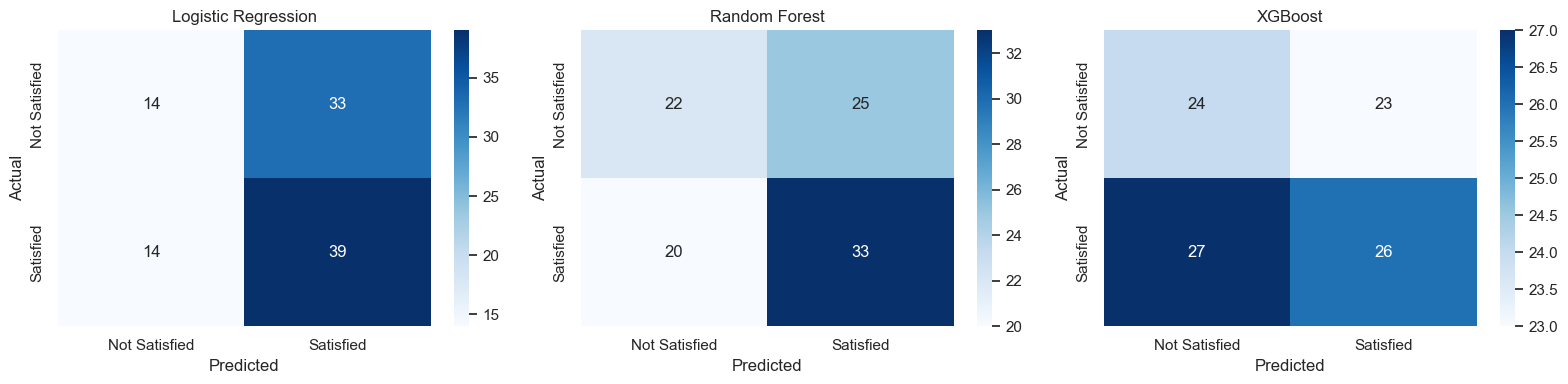

In [41]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, (model, _)) in zip(axes, trained.items()):
    X_te = X_test_scaled if name == 'Logistic Regression' else X_test
    preds = model.predict(X_te)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Satisfied', 'Satisfied'],
                yticklabels=['Not Satisfied', 'Satisfied'])
    ax.set_title(name)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

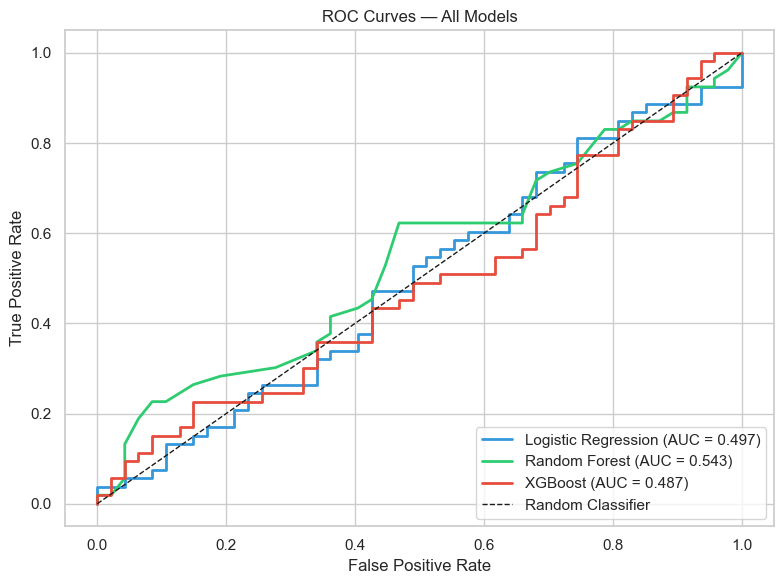

In [42]:
# ROC Curves for all models
plt.figure(figsize=(8, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c']

for (name, (model, _)), color in zip(trained.items(), colors):
    X_te = X_test_scaled if name == 'Logistic Regression' else X_test
    probs = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()